## Extract and compute

In [39]:
import json

benchmark_runs = []
with open("results/benchmark_runs.jsonl") as f:
    for line in f:
        benchmark_runs.append(json.loads(line))

with open("results/analytical_runs.jsonl") as f:
    for line in f:
        benchmark_runs.append(json.loads(line))


In [40]:
benchmark_list = [
    "9_bus",
    "12_bus",
    "15_bus", 
    "33_bus"
]
category_list = ["state-of-art", "classical", "quantum"]
sim_type = [
    #state-of-art
    "genetic",
    "simulated_annealing_pp",
    "simulated_annealing_dnr_pp",
    "baran",
    "merlin",
    "taylor",
    
    #classical
    "classical_NN_2",
    "classical_NN_3", 
    "classical_NN_4", 
    "classical_all_2",
    
    #quantum
    "quantum_NN_2", 
    "quantum_NN_2_pp", 
    "quantum_NN_3", 
    "quantum_NN_3_pp", 
    "quantum_NN_4", 
    "quantum_NN_4_pp", 
    "quantum_all_2", 
    "quantum_all_2_pp", 
    "quantum_all_3", 
    "quantum_all_3_pp",
]

In [ ]:
import json
import math
import statistics
from easy_dnr import DNR_Network


def trunc(x, decimals=2):
    factor = 10 ** decimals
    return math.trunc(x * factor) / factor


def _sum_solver_steps(step_value):
    if isinstance(step_value, (list, tuple)):
        return sum(step_value)
    return step_value if step_value is not None else 0


def analyze_network_sim_type(network_name, sim_name, runs_source):
    runs = sorted(
        [
            r for r in runs_source
            if r.get("network") == network_name and r.get("sim_type") == sim_name
        ],
        key=lambda r: r.get("run_index", 0),
    )

    if not runs:
        return None

    budget = runs[0].get("n_runs_budgeted")
    if budget is not None and len(runs) != budget:
        print(f"Warning [{network_name}/{sim_name}]: expected {budget} runs, found {len(runs)}")

    category = runs[0].get("category", "unknown")
    is_analytical = category == "analytical"

    best_objectives = []
    all_objectives = []
    steps_per_run = []
    circuit_depth = None

    for r in runs:
        obj = None
        details = r.get("details")

        if isinstance(details, dict) and "objective" in details:
            obj = float(details["objective"])
            all_objectives.append(obj)
        elif isinstance(details, list):
            candidates = [d["objective"] for d in details if isinstance(d, dict) and "objective" in d]
            if candidates:
                obj = float(min(candidates))
                all_objectives.extend(candidates)

        if obj is None:
            values = r.get("matching_pursuit", {}).get("values", [])
            if values:
                obj = float(min(values))
                all_objectives.extend(values)

        if obj is None:
            raise ValueError(f"No objective found for run_index={r.get('run_index')}")

        best_objectives.append(obj)

        metadata = r.get("optimizer_metadata", [])
        if metadata:
            if circuit_depth is None:
                circuit_depth = metadata[0].get("circuit_depth")
            steps_per_run.append(
                sum(_sum_solver_steps(m.get("solver_steps", 0)) for m in metadata)
            )

    finite_best = [x for x in best_objectives if math.isfinite(x)]
    finite_all = [x for x in all_objectives if math.isfinite(x)]

    if not finite_best:
        print(f"{network_name} / {sim_name}")
        print("No finite best objective found, skipping quality evaluation.")
        print("-" * 72)
        return {
            "network": network_name,
            "sim_type": sim_name,
            "category": category,
            "n_runs": len(best_objectives),
            "best_of_best": float("inf"),
        }

    dnr_net = DNR_Network(network_name)
    best_of_best = min(finite_best)
    feasible_quality, full_quality = dnr_net.evaluate_quality(best_of_best, folder="data")

    result = {
        "network": network_name,
        "category": category,
        "sim_type": sim_name,
        "n_runs": len(best_objectives),
        "best_of_best": best_of_best,
        "best_of_best_quality_feasible": feasible_quality,
        "best_of_best_quality_full": full_quality,
    }

    print(f"{network_name} / {sim_name}")
    print(f"n_runs = {len(best_objectives)}")
    print(f"Best of Best (best objective min) = {best_of_best:.15f}")
    print(f"Best of Best percentile rank (feasible space) = {trunc(feasible_quality, 2):.2f}")
    print(f"Best of Best percentile rank (full space) = {trunc(full_quality, 2):.2f}")

    if is_analytical:
        print("Analytical method: skipping mean/std/feasibility summaries.\n")
        print("-" * 72)
        return result

    mean_of_best = statistics.mean(finite_best)
    feasible_quality_mean, full_quality_mean = dnr_net.evaluate_quality(mean_of_best, folder="data")
    std_of_best = statistics.stdev(finite_best) if len(finite_best) > 1 else 0.0
    feasibility_rate = len(finite_best) / len(best_objectives)
    feasibility_rate_all = (len(finite_all) / len(all_objectives)) if all_objectives else 0.0

    # Quality range over ±1 objective std:
    # lower objective = better solution = higher percentile rank, so q_hi > q_lo
    q_hi, _ = dnr_net.evaluate_quality(mean_of_best - std_of_best, folder="data")
    q_lo, _ = dnr_net.evaluate_quality(mean_of_best + std_of_best, folder="data")
    quality_range_feasible = q_hi - q_lo   # always >= 0

    print(f"Mean of Best (best objective mean) = {mean_of_best:.15f}")
    print(f"Mean of Best percentile rank (feasible space) = {trunc(feasible_quality_mean, 2):.2f}")
    print(f"Mean of Best percentile rank (full space) = {trunc(full_quality_mean, 2):.2f}\n")

    print(f"Std of Best (best objective) = {std_of_best:.15f}")
    print(f"Quality range over ±1σ (feasible space) = {trunc(quality_range_feasible, 2):.2f} pp  "
          f"(i.e. ±{trunc(quality_range_feasible/2, 2):.2f})\n")
    print(f"feasibility_rate (best_objectives finite count) = {trunc(feasibility_rate, 2):.2f}")
    print(f"feasibility_rate_all (all_objectives finite count) = {trunc(feasibility_rate_all, 2):.2f}")

    if circuit_depth is not None and steps_per_run:
        print(f"credits: circuit_depth = {circuit_depth}, average steps = {statistics.mean(steps_per_run):.2f}")

    print("-" * 72)

    result.update({
        "mean_of_best": mean_of_best,
        "mean_of_best_quality_feasible": feasible_quality_mean,
        "mean_of_best_quality_full": full_quality_mean,
        "std_of_best": std_of_best,
        "quality_range_feasible": quality_range_feasible,
        "feasibility_rate": feasibility_rate,
        "feasibility_rate_all": feasibility_rate_all,
        "circuit_depth": circuit_depth if category == "quantum" else None,
        "average_steps": statistics.mean(steps_per_run) if category == "quantum" else None,
    })
    return result


network_list = benchmark_list if isinstance(globals().get("benchmark_list"), list) else sorted({r.get("network") for r in benchmark_runs if r.get("network")})
sim_type_list = sim_type if isinstance(globals().get("sim_type"), list) else sorted({r.get("sim_type") for r in benchmark_runs if r.get("sim_type")})

results_summary = []
analytical_summary = []
for network_name in network_list:
    for sim_name in sim_type_list:
        result = analyze_network_sim_type(network_name, sim_name, benchmark_runs)
        if result is None:
            continue
        if result.get("category") == "analytical":
            analytical_summary.append(result)
        else:
            results_summary.append(result)

with open("results/results_analysis.jsonl", "w") as f:
    for row in results_summary:
        f.write(json.dumps(row) + "\n")

with open("results/results_analysis_analytical.jsonl", "w") as f:
    for row in analytical_summary:
        f.write(json.dumps(row) + "\n")

print(f"Computed {len(results_summary)} non-analytical combinations.")
print(f"Computed {len(analytical_summary)} analytical combinations.")
print("Saved JSONL to results/results_analysis.jsonl and results/results_analysis_analytical.jsonl")

9_bus / genetic
n_runs = 30
Best of Best (best objective min) = 0.001539821798034
Best of Best percentile rank (feasible space) = 100.00
Best of Best percentile rank (full space) = 100.00
Mean of Best (best objective mean) = 0.001539821798034
Mean of Best percentile rank (feasible space) = 100.00
Mean of Best percentile rank (full space) = 100.00

Std of Best (best objective) = 0.000000000000000
Quality range over ±1σ (feasible space) = 0.00 pp  (i.e. ±0.00)

feasibility_rate (best_objectives finite count) = 1.00
feasibility_rate_all (all_objectives finite count) = 1.00
------------------------------------------------------------------------
9_bus / simulated_annealing_pp
n_runs = 30
Best of Best (best objective min) = 0.001539821798034
Best of Best percentile rank (feasible space) = 100.00
Best of Best percentile rank (full space) = 100.00
Mean of Best (best objective mean) = 0.001539821798034
Mean of Best percentile rank (feasible space) = 100.00
Mean of Best percentile rank (full sp

## Display

In [7]:

# ─── Visualization setup ──────────────────────────────────────────────────────
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
})

# Display names (PP = post-processing)
SIM_LABELS = {
    "genetic":                    "Genetic",
    "simulated_annealing_pp":     "Simulated Annealing",
    "classical_NN_2":             "CL NN-2",
    "classical_NN_3":             "CL NN-3",
    "classical_NN_4":             "CL NN-4",
    "classical_all_2":            "CL All-2",
    "quantum_NN_2":               "Q NN-2",
    "quantum_NN_2_pp":            "Q NN-2+PP",
    "quantum_NN_3":               "Q NN-3",
    "quantum_NN_3_pp":            "Q NN-3+PP",
    "quantum_NN_4":               "Q NN-4",
    "quantum_NN_4_pp":            "Q NN-4+PP",
    "quantum_all_2":              "Q All-2",
    "quantum_all_2_pp":           "Q All-2+PP",
    "quantum_all_3":              "Q All-3",
    "quantum_all_3_pp":           "Q All-3+PP",
}

CAT_ORDER  = ["state-of-art", "classical", "quantum"]
CAT_COLORS = {"state-of-art": "#1565C0", "classical": "#2E7D32", "quantum": "#E65100"}
ANA_COLORS = {"baran": "#333333", "merlin": "#777777", "taylor": "#BBBBBB"}
ANA_STYLES = {"baran": "--", "merlin": "-.", "taylor": ":"}
NET_ORDER  = ["9_bus", "12_bus", "15_bus", "33_bus"]
NET_LABELS = {"9_bus": "9-bus", "12_bus": "12-bus", "15_bus": "15-bus", "33_bus": "33-bus"}

# Load from JSONL directly (works without re-running analysis cell)
with open("results/results_analysis.jsonl") as f:
    df = pd.DataFrame(json.loads(l) for l in f)

with open("results/results_analysis_analytical.jsonl") as f:
    df_ana = pd.DataFrame(json.loads(l) for l in f)

# Quantum base ↔ pp pairs (used in Figure 4)
PP_PAIRS = [
    ("quantum_NN_2",  "quantum_NN_2_pp"),
    ("quantum_NN_3",  "quantum_NN_3_pp"),
    ("quantum_NN_4",  "quantum_NN_4_pp"),
    ("quantum_all_2", "quantum_all_2_pp"),
    ("quantum_all_3", "quantum_all_3_pp"),
]
# SA methods are always pp-only (no non-pp baseline exists)
SA_PP_ONLY = ["simulated_annealing_pp"]

# Exclude only quantum pp variants (the ones that have a base counterpart).
# SA+PP has no base version so it stays in the main plots.
QUANTUM_PP_SIMS = {p for _, p in PP_PAIRS}
df = df[df["sim_type"] != "simulated_annealing_dnr_pp"].copy()
df["is_quantum_pp"] = df["sim_type"].isin(QUANTUM_PP_SIMS)
df_nopp = df[~df["is_quantum_pp"]].copy()   # used by Figures 1–3

# Solver ordering per category — full (for Fig 4) and no-quantum-pp (for Figs 1–3)
SIMS_BY_CAT = {
    cat: [s for s in SIM_LABELS if s in df.loc[df.category == cat, "sim_type"].values]
    for cat in CAT_ORDER
}
SIMS_BY_CAT_NOPP = {
    cat: [s for s in sims if s not in QUANTUM_PP_SIMS]
    for cat, sims in SIMS_BY_CAT.items()
}

print(f"Loaded {len(df)} solver-network rows | {len(df_ana)} analytical rows")
print(f"  Quantum-PP excluded from Figs 1–3: {sorted(QUANTUM_PP_SIMS)}")
print(f"  SA pp-only (kept in Figs 1–3): {SA_PP_ONLY[0]}")
for cat, sims in SIMS_BY_CAT_NOPP.items():
    print(f"  {cat}: {[SIM_LABELS[s] for s in sims]}")


Loaded 47 solver-network rows | 12 analytical rows
  Quantum-PP excluded from Figs 1–3: ['quantum_NN_2_pp', 'quantum_NN_3_pp', 'quantum_NN_4_pp', 'quantum_all_2_pp', 'quantum_all_3_pp']
  SA pp-only (kept in Figs 1–3): simulated_annealing_pp
  state-of-art: ['Genetic', 'Simulated Annealing']
  classical: ['CL NN-2', 'CL NN-3', 'CL NN-4', 'CL All-2']
  quantum: ['Q NN-2', 'Q NN-3', 'Q NN-4', 'Q All-2', 'Q All-3']


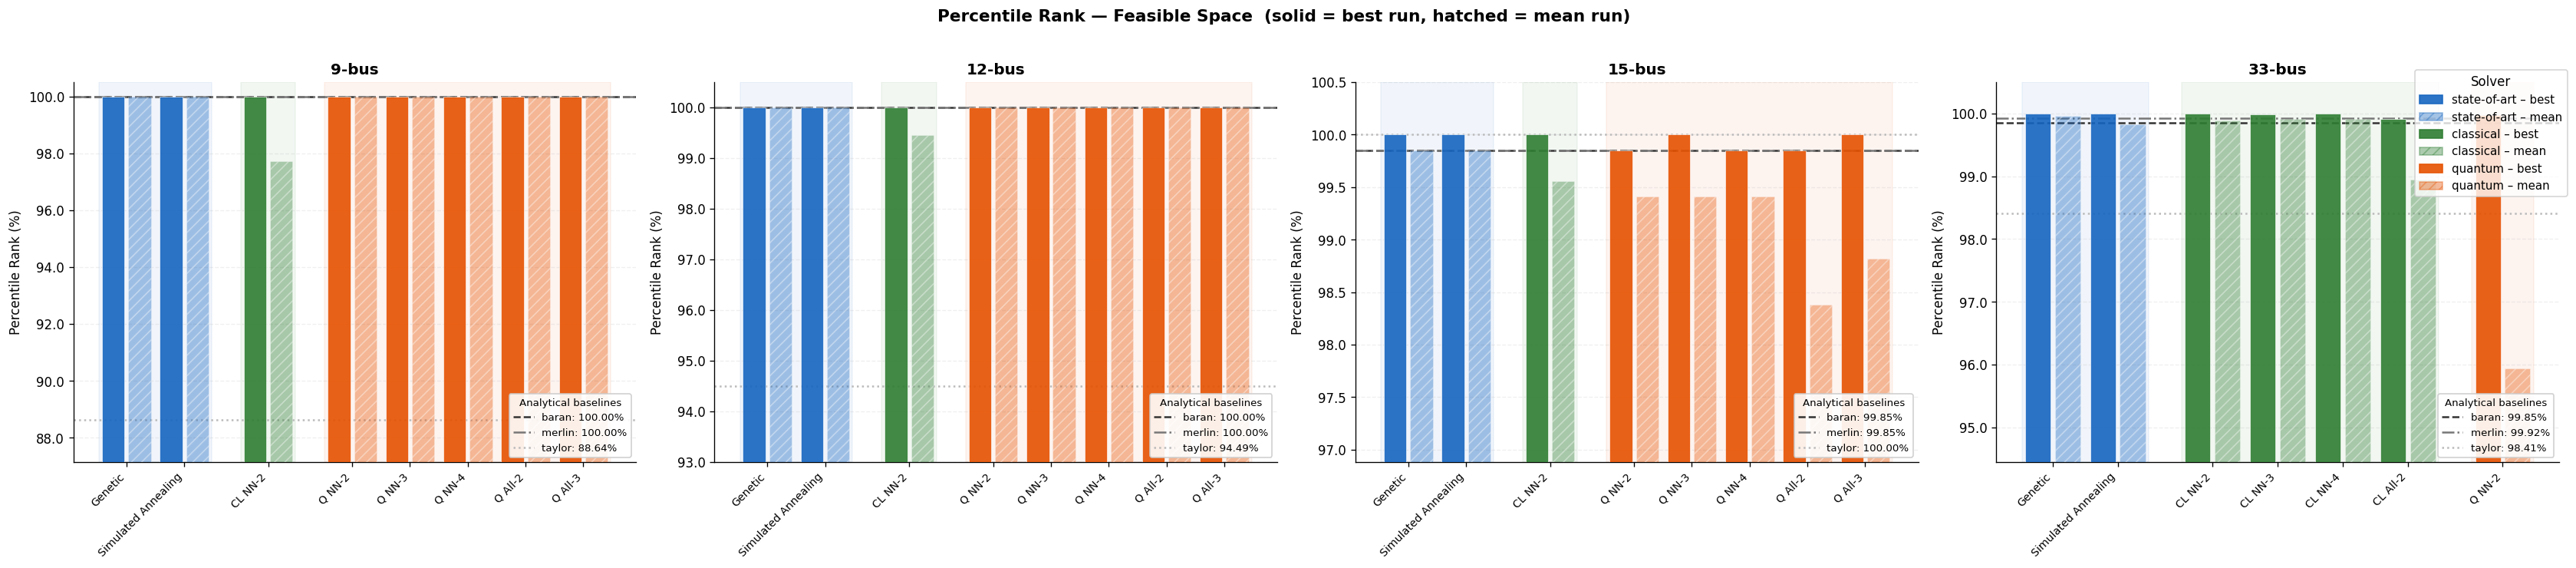

In [8]:

# ─── Figure 1: Percentile Rank Comparison — no-PP methods only ───────────────

W    = 0.30
PGAP = 0.05
SGAP = 0.12
CGAP = 0.35

fig, axes = plt.subplots(1, 4, figsize=(28, 6))
fig.suptitle("Percentile Rank — Feasible Space  (solid = best run, hatched = mean run)",
             fontsize=13, fontweight="bold", y=1.02)

for ax, net in zip(axes, NET_ORDER):
    sub     = df_nopp[df_nopp.network == net]
    sub_ana = df_ana[df_ana.network == net]

    entries   = []
    cat_spans = {}
    x = W / 2
    prev_cat = None

    for cat in CAT_ORDER:
        for sim in SIMS_BY_CAT_NOPP[cat]:
            if sub[sub.sim_type == sim].empty:
                continue
            if prev_cat is not None and cat != prev_cat:
                x += CGAP
            x_b = x
            x_m = x + W + PGAP
            x_t = x + (W + PGAP) / 2
            entries.append((sim, cat, x_b, x_m, x_t))
            cat_spans.setdefault(cat, [x - W / 2, None])
            cat_spans[cat][1] = x_m + W / 2
            x += 2 * W + PGAP + SGAP
            prev_cat = cat

    for sim, cat, x_b, x_m, _ in entries:
        row   = sub[sub.sim_type == sim].iloc[0]
        color = CAT_COLORS[cat]
        best  = row["best_of_best_quality_feasible"]
        mean  = row.get("mean_of_best_quality_feasible", np.nan)
        ax.bar(x_b, best, W, color=color, alpha=0.9, edgecolor="white", lw=0.4, zorder=3)
        if pd.notna(mean):
            ax.bar(x_m, mean, W, color=color, alpha=0.38, hatch="///",
                   edgecolor="white", lw=0.4, zorder=3)

    for cat, (x0, x1) in cat_spans.items():
        ax.axvspan(x0 - 0.04, x1 + 0.04, alpha=0.06, color=CAT_COLORS[cat], zorder=0)

    for _, ar in sub_ana.iterrows():
        s = ar.sim_type
        q = ar.best_of_best_quality_feasible
        ax.axhline(q, color=ANA_COLORS[s], ls=ANA_STYLES[s], lw=1.5,
                   label=f"{s}: {q:.2f}%", zorder=2)

    ax.set_xticks([e[4] for e in entries])
    ax.set_xticklabels([SIM_LABELS.get(e[0], e[0]) for e in entries],
                       rotation=45, ha="right", fontsize=8.5)
    ax.set_title(NET_LABELS[net], fontsize=12, fontweight="bold")
    ax.set_ylabel("Percentile Rank (%)")

    q_all = pd.concat([sub["best_of_best_quality_feasible"],
                       sub["mean_of_best_quality_feasible"],
                       sub_ana["best_of_best_quality_feasible"]]).dropna()
    ax.set_ylim(max(0, q_all.min() - 1.5), 100.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f}"))
    ax.grid(axis="y", alpha=0.2, ls="--", zorder=1)
    ax.legend(title="Analytical baselines", title_fontsize=8,
              loc="lower right", fontsize=8, framealpha=0.9)

handles = []
for cat in CAT_ORDER:
    c = CAT_COLORS[cat]
    handles += [
        mpatches.Patch(color=c, alpha=0.9,  label=f"{cat} – best"),
        mpatches.Patch(color=c, alpha=0.38, hatch="///", label=f"{cat} – mean"),
    ]
fig.legend(handles=handles, bbox_to_anchor=(1.0, 0.92),
           fontsize=9, frameon=True, ncol=1, title="Solver")

plt.tight_layout()
plt.savefig("figures/fig1_quality.pdf", bbox_inches="tight")
plt.show()


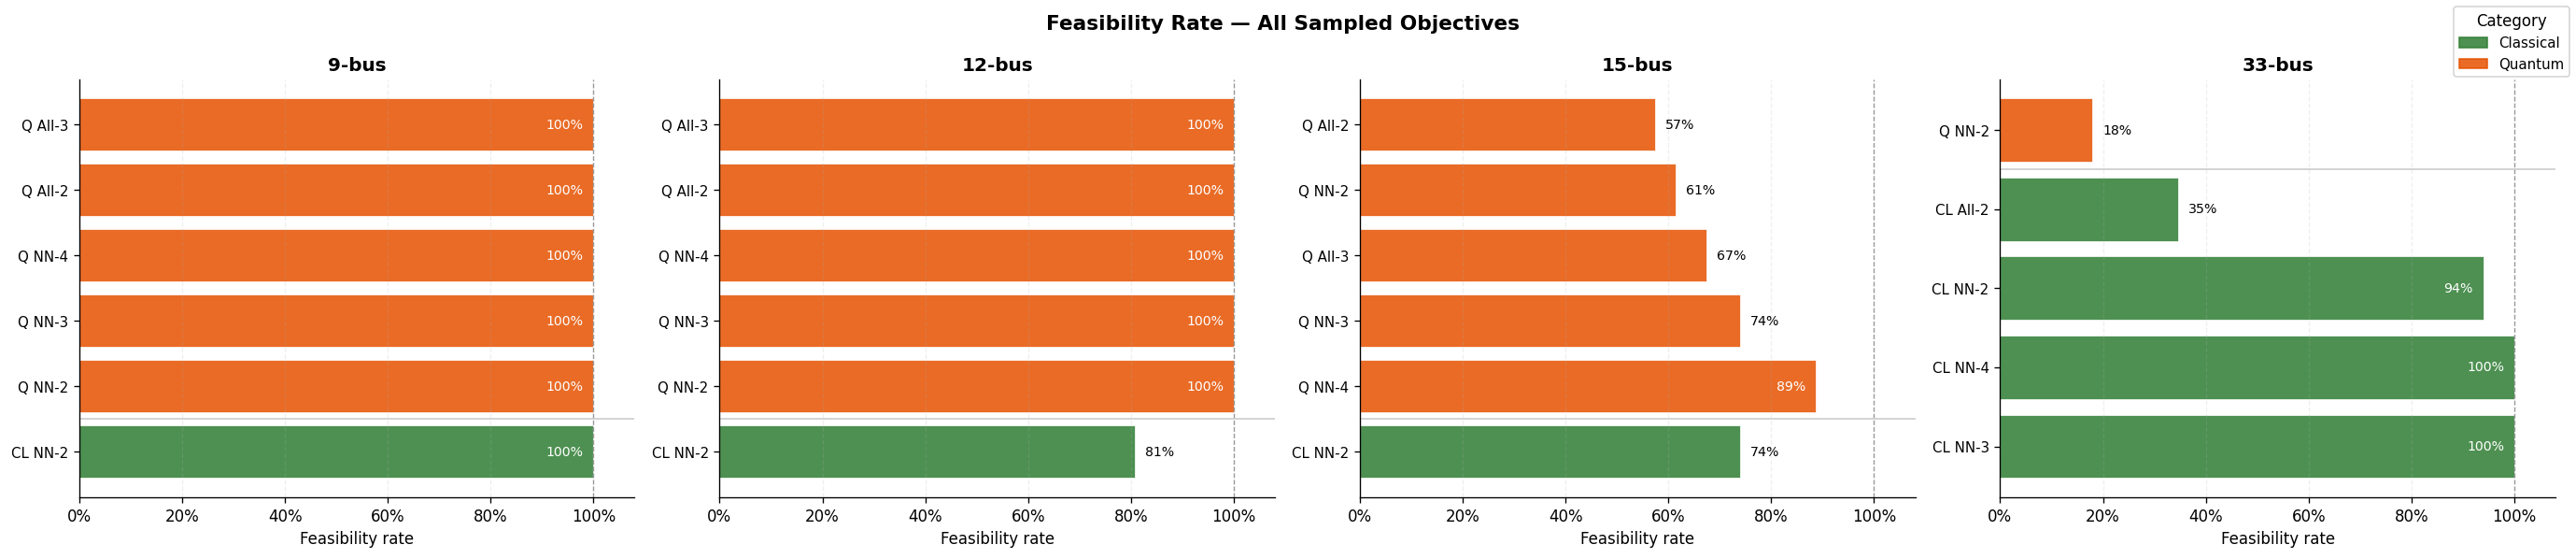

In [9]:

# ─── Figure 2: Feasibility Rate — no-PP methods only ─────────────────────────

# Genetic and Simulated Annealing always reach 100% feasibility — drop them here.
FIG2_EXCLUDED_SIMS = {"genetic", "simulated_annealing_pp"}
df_fig2 = df_nopp[~df_nopp.sim_type.isin(FIG2_EXCLUDED_SIMS)]

fig, axes = plt.subplots(1, 4, figsize=(23, 5), sharey=False)
fig.suptitle("Feasibility Rate — All Sampled Objectives",
             fontsize=13, fontweight="bold")

for ax, net in zip(axes, NET_ORDER):
    sub = df_fig2[df_fig2.network == net].copy()

    cat_rank = {c: i for i, c in enumerate(CAT_ORDER)}
    sub["_cr"] = sub["category"].map(cat_rank)
    sub = sub.sort_values(["_cr", "feasibility_rate_all"], ascending=[True, False])

    colors = [CAT_COLORS[c] for c in sub["category"]]
    y      = np.arange(len(sub))
    bars   = ax.barh(y, sub["feasibility_rate_all"],
                     color=colors, alpha=0.85, edgecolor="white", lw=0.5)

    for bar, val in zip(bars, sub["feasibility_rate_all"]):
        inside = val > 0.88
        ax.text(
            val - 0.02 if inside else val + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.0%}",
            va="center", ha="right" if inside else "left",
            fontsize=8.5, color="white" if inside else "black",
        )

    ax.set_yticks(y)
    ax.set_yticklabels([SIM_LABELS.get(s, s) for s in sub["sim_type"]], fontsize=9)
    ax.set_xlim(0, 1.08)
    ax.set_xlabel("Feasibility rate")
    ax.set_title(NET_LABELS[net], fontsize=12, fontweight="bold")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.axvline(1.0, color="#999", lw=0.8, ls="--")
    ax.grid(axis="x", alpha=0.2, ls="--")

    prev_cat = None
    for i, cat in enumerate(sub["category"]):
        if prev_cat is not None and cat != prev_cat:
            ax.axhline(i - 0.5, color="#ccc", lw=1.0, ls="-")
        prev_cat = cat

present_cats = [c for c in CAT_ORDER if not df_fig2[df_fig2.category == c].empty]
handles = [mpatches.Patch(color=CAT_COLORS[c], alpha=0.85, label=c.title())
           for c in present_cats]
fig.legend(handles=handles, loc="upper right", fontsize=9,
           title="Category", frameon=True)

plt.tight_layout()
plt.savefig("figures/fig2_feasibility.pdf", bbox_inches="tight")
plt.show()


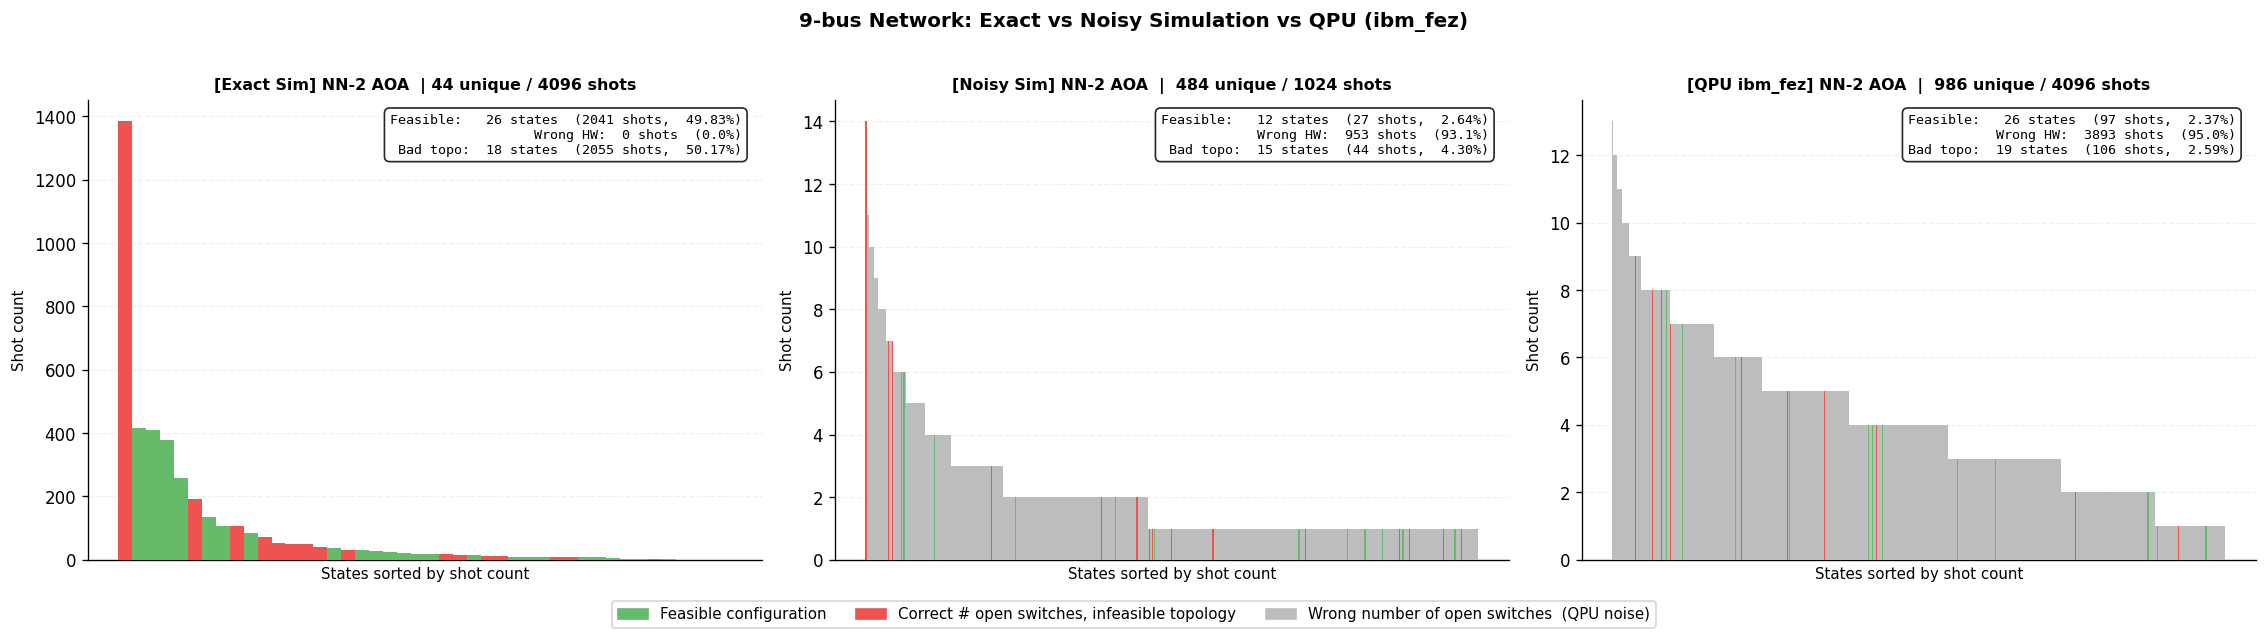

In [10]:
# ─── Figure 3a: 9-bus — Simulation vs Noisy Simulation vs QPU ────────────────

import json as _json, math
import matplotlib.patches as mpatches
from easy_dnr import DNR_Network

COLOR_INF_HW   = "#BDBDBD"   # grey   - wrong number of open switches (QPU noise)
COLOR_INF_TOPO = "#EF5350"   # red    - correct #open switches but infeasible topology
COLOR_FEASIBLE = "#66BB6A"   # green  - finite objective (feasible)
PALETTE = (COLOR_FEASIBLE, COLOR_INF_TOPO, COLOR_INF_HW)


def _state_feasibility(dist, dnr_net, palette):
    feasible_c, topo_c, hw_c = palette
    n_sw, n_cl = dnr_net.n_switches, dnr_net.n_closed_switches
    colors = {}
    stats = dict(shots_inf_hw=0, shots_inf_topo=0, shots_feasible=0,
                  states_feasible=0, states_inf_topo=0)
    for key, cnt in dist.items():
        si = int(key)
        sw = [(si >> (n_sw - 1 - i)) & 1 for i in range(n_sw)]
        if sum(sw) != n_cl:
            colors[key] = hw_c
            stats["shots_inf_hw"] += cnt
        else:
            obj = dnr_net.evaluate(sw)
            if math.isfinite(obj):
                colors[key] = feasible_c
                stats["shots_feasible"] += cnt
                stats["states_feasible"] += 1
            else:
                colors[key] = topo_c
                stats["shots_inf_topo"] += cnt
                stats["states_inf_topo"] += 1
    return colors, stats


def _plot_distribution(ax, dist, dnr_net, palette, title):
    colors, stats = _state_feasibility(dist, dnr_net, palette)
    total_shots = sum(dist.values())

    sorted_states = sorted(dist.items(), key=lambda x: -x[1])
    counts     = [c for _, c in sorted_states]
    bar_colors = [colors[k] for k, _ in sorted_states]

    ax.bar(range(len(sorted_states)), counts,
           color=bar_colors, edgecolor="none", width=1.0, zorder=3)

    ax.set_title(title, fontsize=9.5, fontweight="bold")
    ax.set_xlabel("States sorted by shot count", fontsize=9)
    ax.set_ylabel("Shot count", fontsize=9)
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.2, ls="--", zorder=1)

    ax.text(
        0.97, 0.97,
        f"Feasible:   {stats['states_feasible']} states  ({stats['shots_feasible']} shots,  "
        f"{stats['shots_feasible']/total_shots:.2%})\n"
        f"Wrong HW:  {stats['shots_inf_hw']} shots  "
        f"({stats['shots_inf_hw']/total_shots:.1%})\n"
        f"Bad topo:  {stats['states_inf_topo']} states  ({stats['shots_inf_topo']} shots,  "
        f"{stats['shots_inf_topo']/total_shots:.2%})",
        transform=ax.transAxes, fontsize=8, va="top", ha="right", family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85),
    )


def _best_nn2_run(network):
    for sim in ("quantum_NN_2", "quantum_NN_2_pp"):
        runs = [
            r for r in benchmark_runs
            if r.get("network") == network and r.get("sim_type") == sim
            and (r.get("optimizer_metadata") or [{}])[0].get("final_sample_distribution")
        ]
        if runs:
            return sim, min(runs, key=lambda r: min(d["objective"] for d in r["details"]))
    return None, None


_9bus_dnr = DNR_Network("9_bus")

# Panel 1 — Simulation NN-2
_sim_type_9, _sim_run_9 = _best_nn2_run("9_bus")
_sim_meta_9 = _sim_run_9["optimizer_metadata"][0]
_sim_dist_9 = _sim_meta_9["final_sample_distribution"]

# Panel 2 — Noisy simulation (first run in the FAKE file = top-left of Fig 3b)
with open("results/qpu_runs.jsonl") as _f:
    _noisy_run_9 = next(r for r in (_json.loads(l) for l in _f) if r.get("method", {}).get("backend", {}).get("name") == "aer_simulator_statevector_gpu")
_noisy_dist_9 = _noisy_run_9["aoa"]["final_sample_distribution"]
_noisy_meta_9 = _noisy_run_9["optimizer_metadata"][0]

# Panel 3 — QPU native (NN_2_aoa_native)
with open("results/qpu_runs.jsonl") as _f:
    _qpu_native_9 = next(
        r for r in (_json.loads(l) for l in _f)
        if r.get("network") == "9_bus"
        and r.get("method", {}).get("backend", {}).get("name") == "ibm_fez"
        and r.get("sim_type") == "NN_2_aoa_native"
    )
_qpu_native_dist_9 = _qpu_native_9["aoa"]["final_sample_distribution"]
_qpu_native_meta_9 = _qpu_native_9["optimizer_metadata"][0]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle(
    "9-bus Network: Exact vs Noisy Simulation vs QPU (ibm_fez)\n",
    fontsize=12, fontweight="bold",
)

_plot_distribution(
    axes[0], _sim_dist_9, _9bus_dnr, PALETTE,
    f"[Exact Sim] NN-2 AOA  | "
    f"{len(_sim_dist_9)} unique / {sum(_sim_dist_9.values())} shots",
)
_plot_distribution(
    axes[1], _noisy_dist_9, _9bus_dnr, PALETTE,
    f"[Noisy Sim] NN-2 AOA  |  "
    f"{len(_noisy_dist_9)} unique / {sum(_noisy_dist_9.values())} shots",
)
_plot_distribution(
    axes[2], _qpu_native_dist_9, _9bus_dnr, PALETTE,
    f"[QPU ibm_fez] NN-2 AOA  |  "
    f"{len(_qpu_native_dist_9)} unique / {sum(_qpu_native_dist_9.values())} shots",
)

_leg_handles = [
    mpatches.Patch(color=COLOR_FEASIBLE, label="Feasible configuration"),
    mpatches.Patch(color=COLOR_INF_TOPO, label="Correct # open switches, infeasible topology"),
    mpatches.Patch(color=COLOR_INF_HW,   label="Wrong number of open switches  (QPU noise)"),
]
fig.legend(handles=_leg_handles, loc="lower center", fontsize=9,
           frameon=True, ncol=3, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig("figures/fig_9bus_sim_noisy_qpu.pdf", bbox_inches="tight")
plt.show()

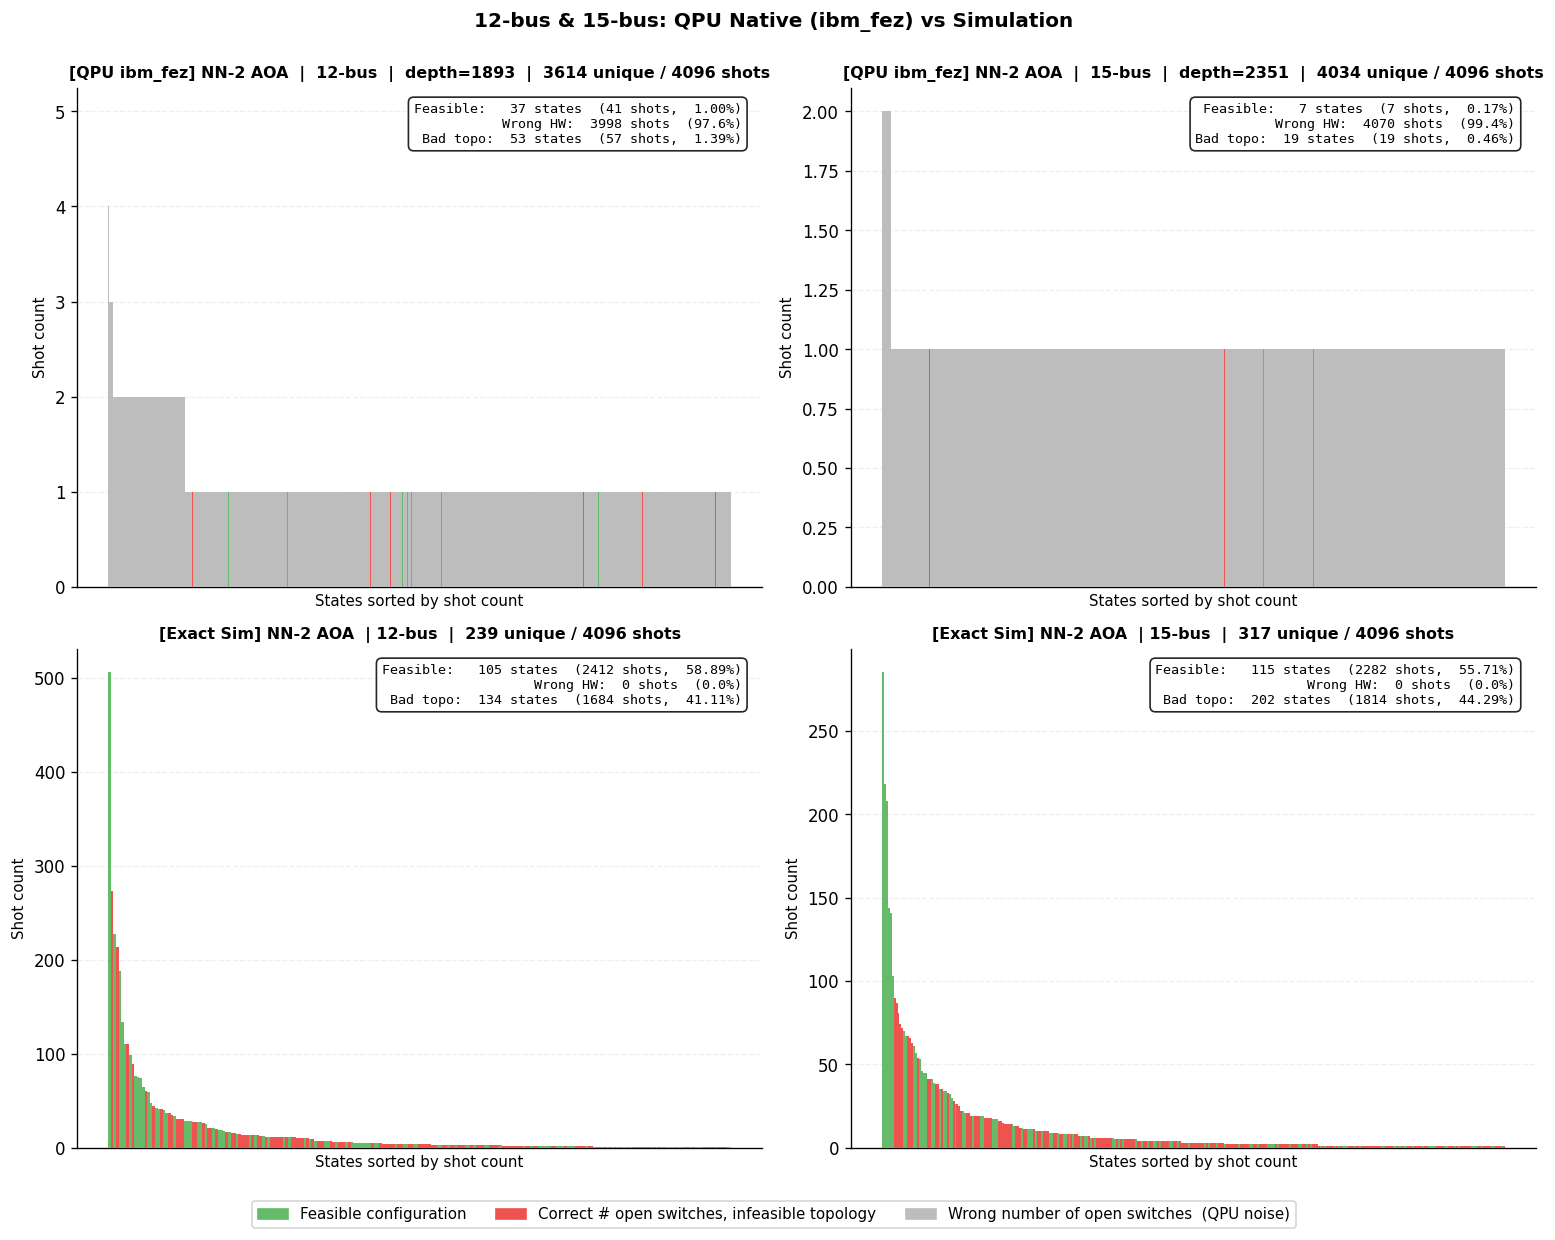

In [11]:
# ─── Figure 3b: 12-bus & 15-bus — QPU Native (top) vs Simulation (bottom) ────

import json as _json

_dnr_12 = DNR_Network("12_bus")
_dnr_15 = DNR_Network("15_bus")

# Simulations
_sim_type_12, _sim_run_12 = _best_nn2_run("12_bus")
_sim_meta_12 = _sim_run_12["optimizer_metadata"][0]
_sim_dist_12 = _sim_meta_12["final_sample_distribution"]

_sim_type_15, _sim_run_15 = _best_nn2_run("15_bus")
_sim_meta_15 = _sim_run_15["optimizer_metadata"][0]
_sim_dist_15 = _sim_meta_15["final_sample_distribution"]

# Native QPU runs
_qpu_native_all = []
with open("results/qpu_runs.jsonl") as _f:
    for l in _f:
        r = _json.loads(l)
        if r.get("network") in ("12_bus", "15_bus") and r.get("method", {}).get("backend", {}).get("name") == "ibm_fez":
            _qpu_native_all.append(r)
_qpu_12_nat = next(r for r in _qpu_native_all if r["network"] == "12_bus" and r["sim_type"] == "NN_2_aoa_native")
_qpu_12_nat_dist = _qpu_12_nat["aoa"]["final_sample_distribution"]
_qpu_12_nat_meta = _qpu_12_nat["optimizer_metadata"][0]

_qpu_15_nat = next(r for r in _qpu_native_all if r["network"] == "15_bus" and r["sim_type"] == "NN_2_aoa_native")
_qpu_15_nat_dist = _qpu_15_nat["aoa"]["final_sample_distribution"]
_qpu_15_nat_meta = _qpu_15_nat["optimizer_metadata"][0]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle(
    "12-bus & 15-bus: QPU Native (ibm_fez) vs Simulation\n",
    fontsize=12, fontweight="bold",
)

# Row 0: QPU native
_plot_distribution(
    axes[0, 0], _qpu_12_nat_dist, _dnr_12, PALETTE,
    f"[QPU ibm_fez] NN-2 AOA  |  12-bus  |  depth={_qpu_12_nat_meta['circuit_depth']}  |  "
    f"{len(_qpu_12_nat_dist)} unique / {sum(_qpu_12_nat_dist.values())} shots",
)
_plot_distribution(
    axes[0, 1], _qpu_15_nat_dist, _dnr_15, PALETTE,
    f"[QPU ibm_fez] NN-2 AOA  |  15-bus  |  depth={_qpu_15_nat_meta['circuit_depth']}  |  "
    f"{len(_qpu_15_nat_dist)} unique / {sum(_qpu_15_nat_dist.values())} shots",
)

# Row 1: Simulation
_plot_distribution(
    axes[1, 0], _sim_dist_12, _dnr_12, PALETTE,
    f"[Exact Sim] NN-2 AOA  | 12-bus  |  "
    f"{len(_sim_dist_12)} unique / {sum(_sim_dist_12.values())} shots",
)
_plot_distribution(
    axes[1, 1], _sim_dist_15, _dnr_15, PALETTE,
    f"[Exact Sim] NN-2 AOA  | 15-bus  |  "
    f"{len(_sim_dist_15)} unique / {sum(_sim_dist_15.values())} shots",
)

_leg_handles = [
    mpatches.Patch(color=COLOR_FEASIBLE, label="Feasible configuration"),
    mpatches.Patch(color=COLOR_INF_TOPO, label="Correct # open switches, infeasible topology"),
    mpatches.Patch(color=COLOR_INF_HW,   label="Wrong number of open switches  (QPU noise)"),
]
fig.legend(handles=_leg_handles, loc="lower center", fontsize=9,
           frameon=True, ncol=3, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("figures/fig_12_15bus_sim_vs_qpu.pdf", bbox_inches="tight")
plt.show()

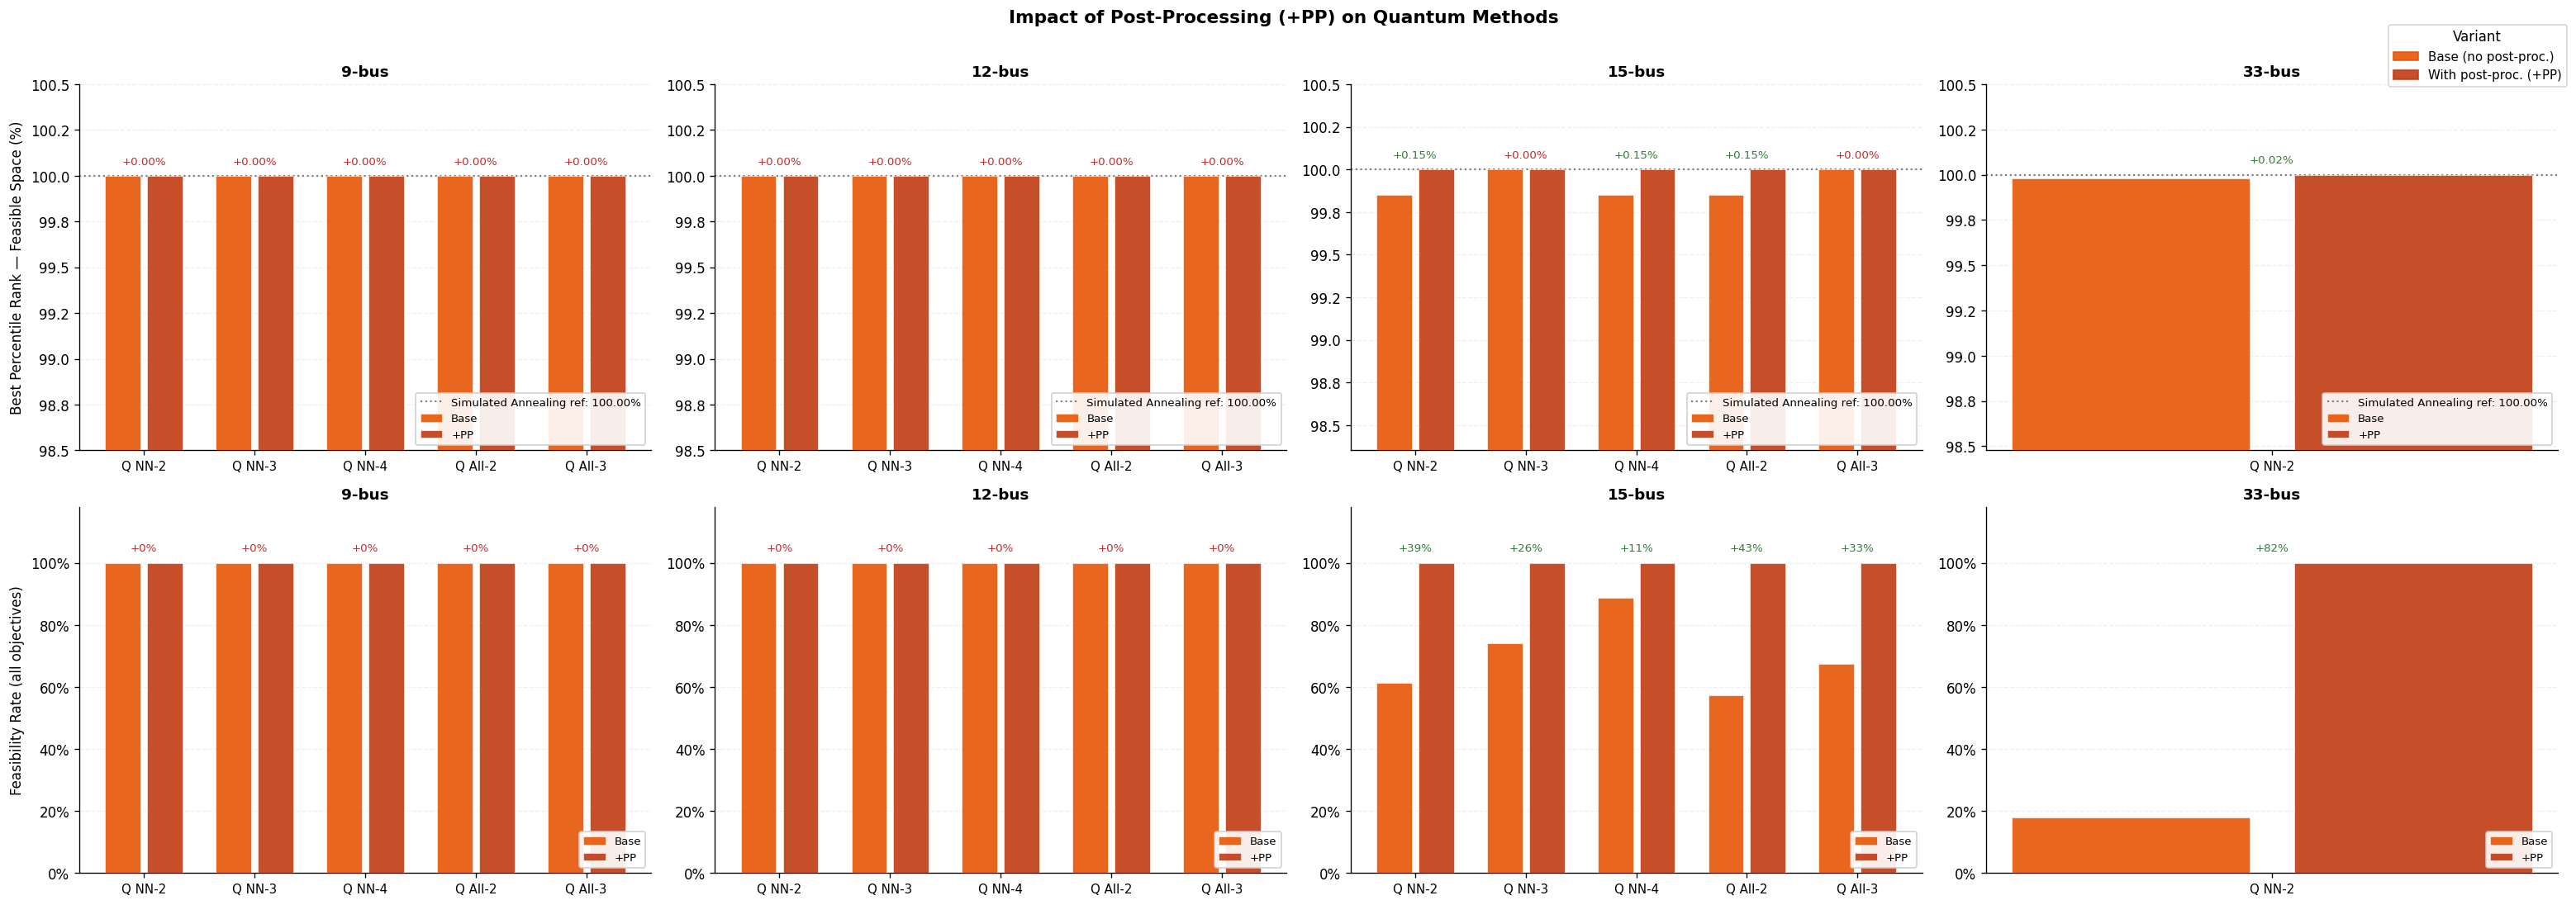

In [12]:

# ─── Figure 4: Impact of Post-Processing (+PP) ────────────────────────────────
# Rows: best percentile rank (feasible) | feasibility rate
# Cols: one per network
# Bars: base (lighter orange) vs +PP (darker orange) for each quantum pair
# Delta annotations show the gain/loss from PP (green = gain, red = loss)
# SA+PP and SA-DNR+PP appear as reference lines on the percentile rank row
# (no base exists for SA — it is always pp-only by design)

BASE_COLOR = CAT_COLORS["quantum"]   # deep orange
PP_COLOR   = "#BF360C"               # darker orange

W_pp = 0.32
GAP  = 0.06

METRICS = [
    ("best_of_best_quality_feasible", "Best Percentile Rank — Feasible Space (%)"),
    ("feasibility_rate_all",          "Feasibility Rate (all objectives)"),
]

fig, axes = plt.subplots(2, 4, figsize=(26, 9))
fig.suptitle("Impact of Post-Processing (+PP) on Quantum Methods",
             fontsize=13, fontweight="bold", y=1.01)

for col_idx, net in enumerate(NET_ORDER):
    sub = df[df.network == net]

    pairs = [
        (b, p) for b, p in PP_PAIRS
        if not sub[sub.sim_type == b].empty and not sub[sub.sim_type == p].empty
    ]
    if not pairs:
        for row_idx in range(2):
            axes[row_idx, col_idx].text(0.5, 0.5, "No data", ha="center", va="center",
                                        transform=axes[row_idx, col_idx].transAxes)
        continue

    x      = np.arange(len(pairs))
    labels = [SIM_LABELS[b] for b, _ in pairs]

    for row_idx, (metric, ylabel) in enumerate(METRICS):
        ax = axes[row_idx, col_idx]

        base_vals = [sub[sub.sim_type == b].iloc[0][metric] for b, _ in pairs]
        pp_vals   = [sub[sub.sim_type == p].iloc[0][metric] for _, p in pairs]

        # Set ylim before drawing so the delta annotations can use a fixed yrange
        if metric == "feasibility_rate_all":
            ax.set_ylim(0, 1.18)
            yrange   = 1.18
            fmt_axis = lambda v, _: f"{v:.0%}"
            fmt_d    = lambda d: f"{'+'if d>=0 else ''}{d:.0%}"
        else:
            ymin = max(0, min(base_vals + pp_vals) - 1.5)
            ax.set_ylim(ymin, 100.5)
            yrange   = 100.5 - ymin
            fmt_axis = lambda v, _: f"{v:.1f}"
            fmt_d    = lambda d: f"{'+'if d>=0 else ''}{d:.2f}%"

        ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_axis))

        ax.bar(x - (W_pp + GAP) / 2, base_vals, W_pp,
               color=BASE_COLOR, alpha=0.88, edgecolor="white", lw=0.4,
               label="Base", zorder=3)
        ax.bar(x + (W_pp + GAP) / 2, pp_vals, W_pp,
               color=PP_COLOR, alpha=0.88, edgecolor="white", lw=0.4,
               label="+PP", zorder=3)

        # Delta annotation above the taller bar of each pair
        for i, (bv, pv) in enumerate(zip(base_vals, pp_vals)):
            delta = pv - bv
            ax.text(x[i], max(bv, pv) + 0.025 * yrange,
                    fmt_d(delta), ha="center", va="bottom", fontsize=8,
                    color="#2E7D32" if delta > 0 else "#C62828")

        # SA pp reference lines on the percentile rank row only
        if metric == "best_of_best_quality_feasible":
            sa_sub = df[(df.network == net) & (df.sim_type.isin(SA_PP_ONLY))]
            for _, sa_row in sa_sub.iterrows():
                sa_lbl = SIM_LABELS.get(sa_row["sim_type"], sa_row["sim_type"])
                q      = sa_row[metric]
                ax.axhline(q, color="#555", ls=":", lw=1.3, alpha=0.75,
                           label=f"{sa_lbl} ref: {q:.2f}%")

        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(NET_LABELS[net], fontsize=11, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(ylabel)
        ax.grid(axis="y", alpha=0.2, ls="--", zorder=1)
        ax.legend(fontsize=8, framealpha=0.9, loc="lower right")

# Shared color legend
handles = [
    mpatches.Patch(color=BASE_COLOR, alpha=0.88, label="Base (no post-proc.)"),
    mpatches.Patch(color=PP_COLOR,   alpha=0.88, label="With post-proc. (+PP)"),
]
fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.0, 1.0),
           fontsize=9, frameon=True, title="Variant")

plt.tight_layout()
plt.savefig("figures/fig4_pp_impact.pdf", bbox_inches="tight")
plt.show()


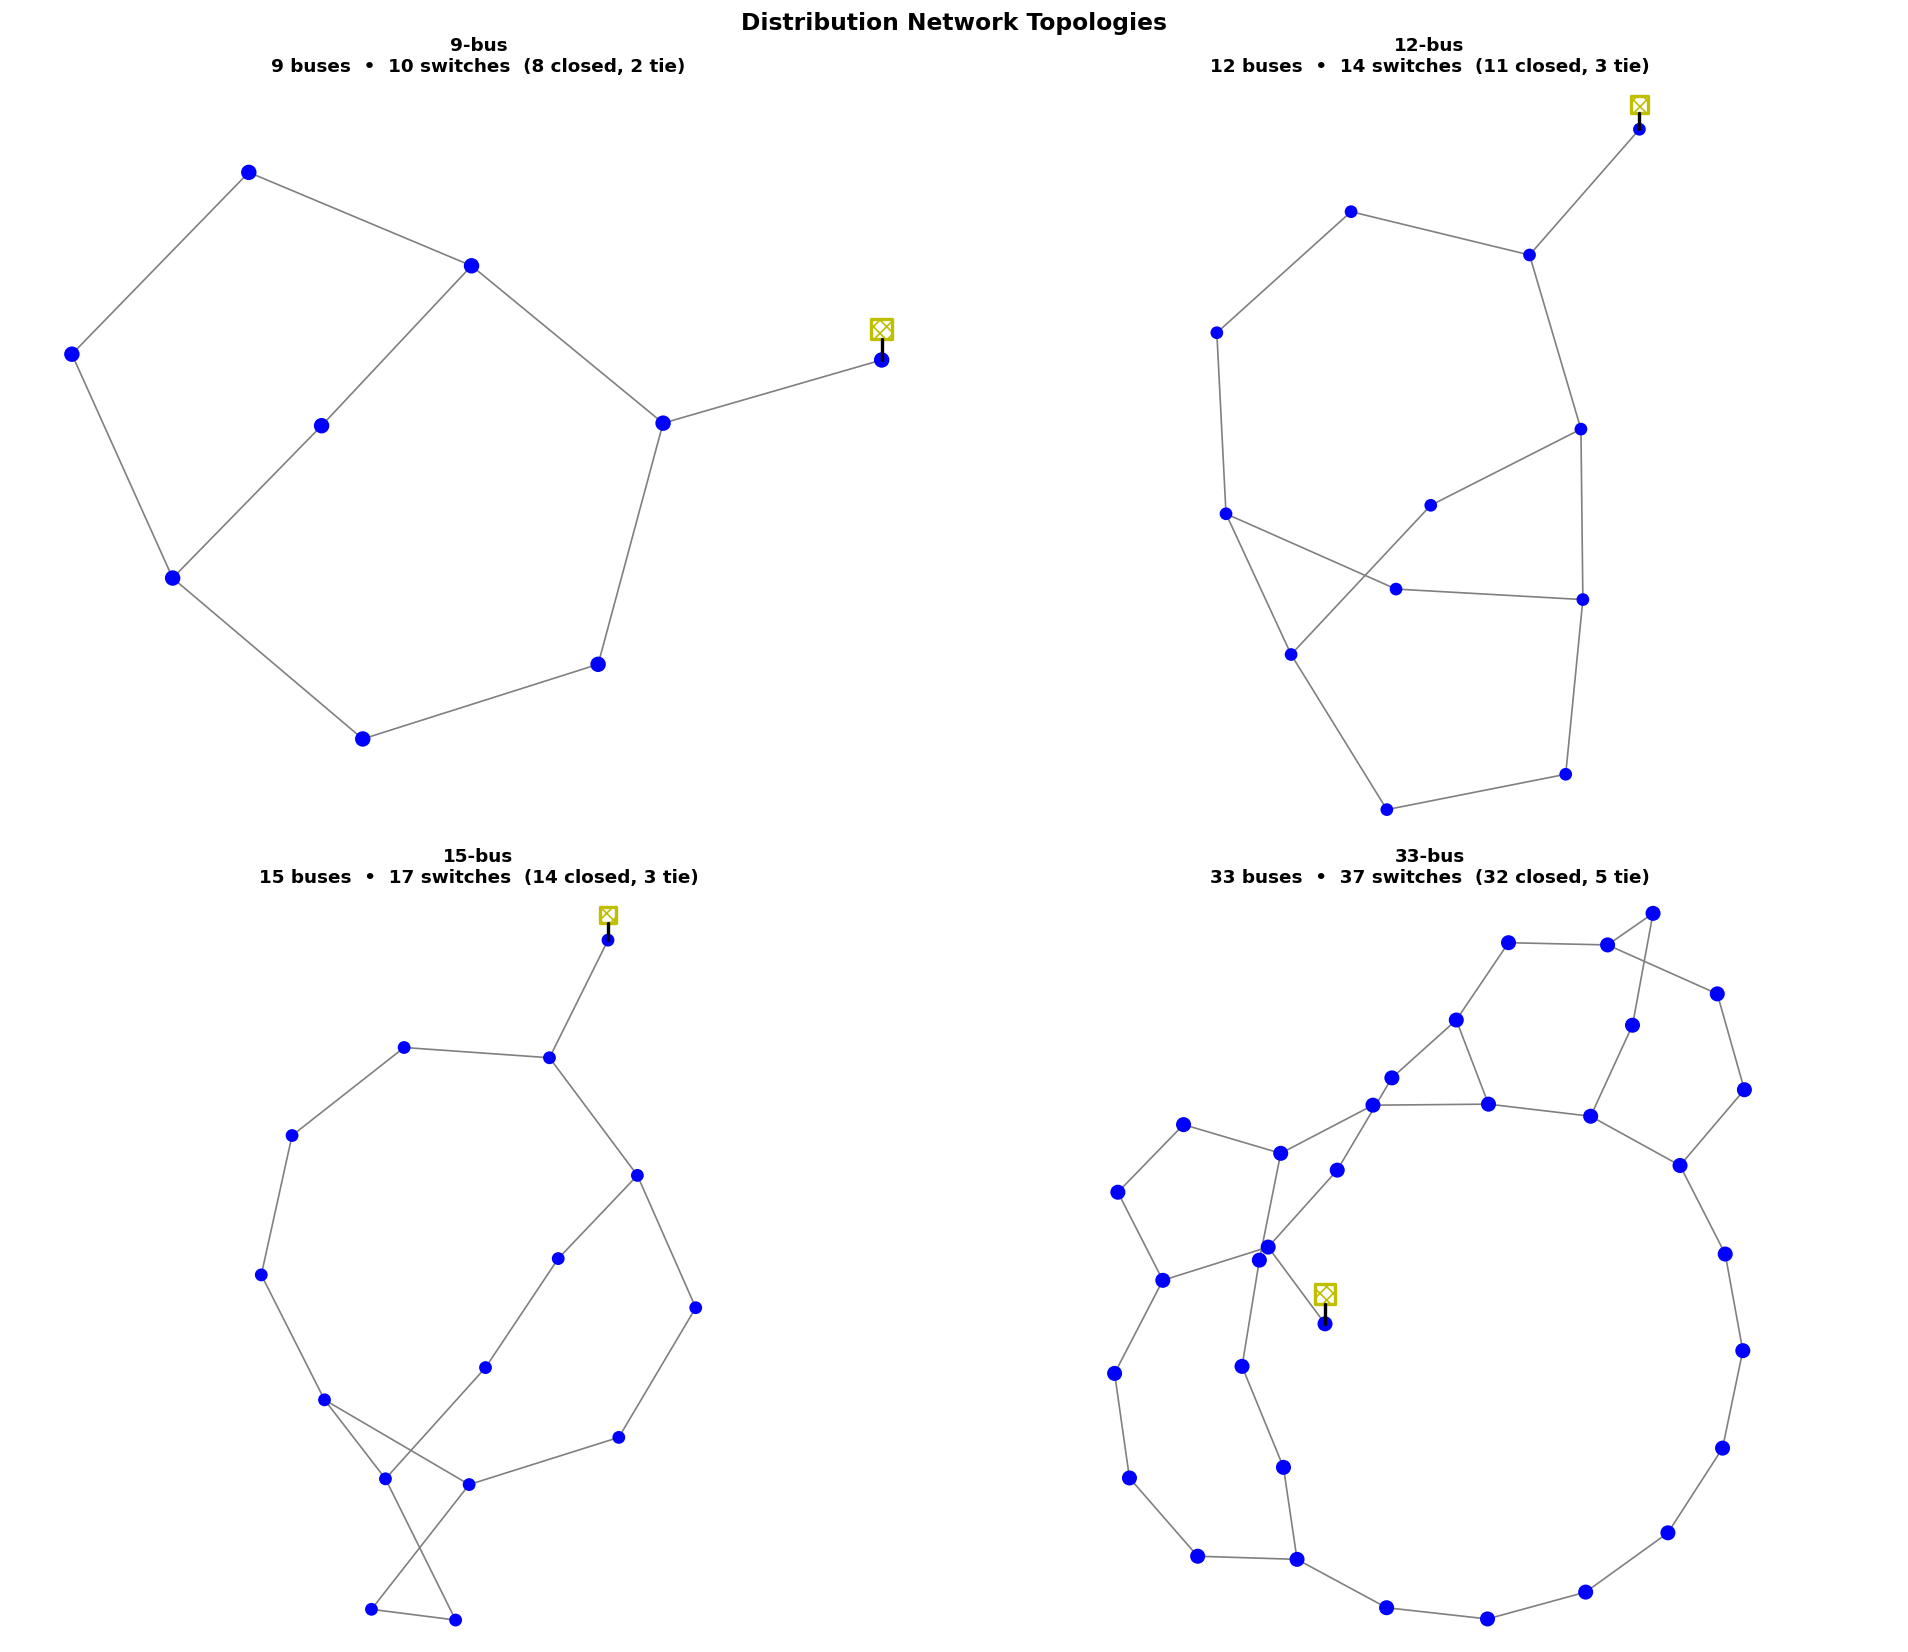

In [13]:
# ─── Figure 5: Distribution Network Topologies ───────────────────────────────
import pandapower.plotting as pp_plot

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle("Distribution Network Topologies", fontsize=14, fontweight='bold')

for ax, net_name in zip(axes.flatten(), NET_ORDER):
    dnr = DNR_Network(net_name)
    dnr._ensure_geodata(dnr.network)
    pp_plot.simple_plot(dnr.network, respect_switches=False, ax=ax, show_plot=False)
    ax.set_title(
        f"{NET_LABELS[net_name]}\n"
        f"{dnr.n_buses} buses  •  {dnr.n_switches} switches  "
        f"({dnr.n_closed_switches} closed, {dnr.n_dits} tie)",
        fontsize=11, fontweight='bold',
    )

plt.tight_layout()
plt.savefig("figures/fig5_networks.pdf", bbox_inches="tight")
plt.show()

In [14]:

# ─── Table: Full Benchmark Summary ────────────────────────────────────────────

def _fmt(x, spec, default="–"):
    try:
        return format(float(x), spec) if pd.notna(x) and x != float("inf") else default
    except (TypeError, ValueError):
        return default

def _fmt_pr(x, decimals=4, default="–"):
    """Floor-truncate percentile rank so near-100 values never round up to 100."""
    try:
        v = float(x)
        if not np.isfinite(v):
            return default
        factor = 10 ** decimals
        return format(np.floor(v * factor) / factor, f".{decimals}f")
    except (TypeError, ValueError):
        return default

def _fmt_range(x, default="–"):
    """Display quality_range_feasible as ±(range/2)."""
    try:
        v = float(x)
        if not np.isfinite(v):
            return default
        return f"±{v/2:.2f}"
    except (TypeError, ValueError):
        return default

cols = [
    "network", "category", "sim_type",
    "best_of_best_quality_feasible", "best_of_best_quality_full",
    "mean_of_best_quality_feasible",
    "quality_range_feasible", "feasibility_rate_all",
    "circuit_depth", "average_steps",
]
tbl = df[cols].copy()

# ── Sort: network → category order → method order (pairs adjacent) ────────────
cat_rank = {c: i for i, c in enumerate(CAT_ORDER)}
sim_rank = {s: i for i, s in enumerate(SIM_LABELS.keys())}
net_rank = {n: i for i, n in enumerate(NET_ORDER)}
tbl["_net_rank"] = tbl["network"].map(net_rank).fillna(99)
tbl["_cat_rank"] = tbl["category"].map(cat_rank).fillna(99)
tbl["_sim_rank"]  = tbl["sim_type"].map(sim_rank).fillna(999)
tbl = tbl.sort_values(["_net_rank", "_cat_rank", "_sim_rank"]).drop(columns=["_net_rank", "_cat_rank", "_sim_rank"])

# ── Format AFTER sorting ──────────────────────────────────────────────────────
tbl["sim_type"]                       = tbl["sim_type"].map(SIM_LABELS).fillna(tbl["sim_type"])
tbl["best_of_best_quality_feasible"]  = tbl["best_of_best_quality_feasible"].map(_fmt_pr)
tbl["best_of_best_quality_full"]      = tbl["best_of_best_quality_full"].map(_fmt_pr)
tbl["mean_of_best_quality_feasible"]  = tbl["mean_of_best_quality_feasible"].map(_fmt_pr)
tbl["quality_range_feasible"]         = tbl["quality_range_feasible"].map(_fmt_range)
tbl["feasibility_rate_all"]           = tbl["feasibility_rate_all"].map(lambda x: _fmt(x, ".1%"))
tbl["circuit_depth"]                  = tbl["circuit_depth"].map(lambda x: _fmt(x, ".0f"))
tbl["average_steps"]                  = tbl["average_steps"].map(lambda x: _fmt(x, ".0f"))

# ── Append analytical rows ────────────────────────────────────────────────────
if not df_ana.empty:
    ana = df_ana[["network", "category", "sim_type",
                  "best_of_best_quality_feasible", "best_of_best_quality_full"]].copy()
    ana["_net_rank"] = ana["network"].map(net_rank).fillna(99)
    ana["_sim_rank"] = ana["sim_type"].map(sim_rank).fillna(999)
    ana = ana.sort_values(["_net_rank", "_sim_rank"]).drop(columns=["_net_rank", "_sim_rank"])
    ana["sim_type"]                      = ana["sim_type"].map(SIM_LABELS).fillna(ana["sim_type"])
    ana["best_of_best_quality_feasible"] = ana["best_of_best_quality_feasible"].map(_fmt_pr)
    ana["best_of_best_quality_full"]     = ana["best_of_best_quality_full"].map(_fmt_pr)
    for c in ["mean_of_best_quality_feasible", "quality_range_feasible",
              "feasibility_rate_all", "circuit_depth", "average_steps"]:
        ana[c] = "–"
    tbl = pd.concat([tbl, ana], ignore_index=True)

tbl = tbl.rename(columns={
    "network":                       "Network",
    "category":                      "Category",
    "sim_type":                      "Solver",
    "best_of_best_quality_feasible": "Best PR (Feas.)",
    "best_of_best_quality_full":     "Best PR (Full)",
    "mean_of_best_quality_feasible": "Mean PR (Feas.)",
    "quality_range_feasible":        "±1σ PR (Feas.)",
    "feasibility_rate_all":          "Feas. Rate",
    "circuit_depth":                 "Depth",
    "average_steps":                 "Steps",
})

# ── Style ─────────────────────────────────────────────────────────────────────
CAT_BG = {
    "state-of-art": "#ddeeff",
    "classical":    "#ddffdd",
    "quantum":      "#fff0e0",
    "analytical":   "#f0f0f0",
}

def _row_bg(row):
    bg = CAT_BG.get(row["Category"], "")
    return [f"background: {bg}"] * len(row)

tbl.style\
    .set_caption("Full Benchmark Results — PR = percentile rank (%). "
                 "±1σ PR = half the quality range spanned by mean ± 1σ of objective.")\
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"),
                                          ("text-align", "left"), ("padding-bottom", "6px")]},
        {"selector": "th",      "props": [("background", "#e8e8e8"), ("font-weight", "bold"),
                                          ("text-align", "center"), ("white-space", "nowrap")]},
        {"selector": "td",      "props": [("text-align", "center")]},
    ])\
    .apply(_row_bg, axis=1)


,Network,Category,Solver,Best PR (Feas.),Best PR (Full),Mean PR (Feas.),±1σ PR (Feas.),Feas. Rate,Depth,Steps
0,9_bus,state-of-art,Genetic,100.0000,100.0000,100.0000,±0.00,100.0%,–,–
1,9_bus,state-of-art,Simulated Annealing,100.0000,100.0000,100.0000,±0.00,100.0%,–,–
2,9_bus,classical,CL NN-2,100.0000,100.0000,97.7272,±1.14,100.0%,–,–
3,9_bus,quantum,Q NN-2,100.0000,100.0000,100.0000,±0.00,100.0%,303,414
4,9_bus,quantum,Q NN-2+PP,100.0000,100.0000,100.0000,±0.00,100.0%,303,416
5,9_bus,quantum,Q NN-3,100.0000,100.0000,100.0000,±0.00,100.0%,447,372
6,9_bus,quantum,Q NN-3+PP,100.0000,100.0000,100.0000,±0.00,100.0%,447,372
7,9_bus,quantum,Q NN-4,100.0000,100.0000,100.0000,±0.00,100.0%,919,375
8,9_bus,quantum,Q NN-4+PP,100.0000,100.0000,100.0000,±0.00,100.0%,919,387
9,9_bus,quantum,Q All-2,100.0000,100.0000,100.0000,±0.00,100.0%,335,422


In [44]:
# ─── Export table as LaTeX ───────────────────────────────────────────────────
# Requires in preamble:
#   \usepackage{booktabs, xcolor, colortbl}
# Include with:  \input{figures/table_benchmark.tex}

_CAT_TEX_COLOR = {
    "state-of-art": "blue!10",
    "classical":    "green!10",
    "quantum":      "orange!12",
    "analytical":   "gray!10",
}

_tbl_raw = tbl.copy()
_cat_col = "Category"

def _esc(v):
    s = str(v)
    s = s.replace("%", r"\%").replace("_", r"\_").replace("&", r"\&")
    # preserve ± as-is (valid in text mode with \usepackage[T1]{fontenc} or just works)
    return s

lines = []
lines.append(r"\begin{table}[ht]")
lines.append(r"\centering")
lines.append(
    r"\caption{Full Benchmark Results. All percentile ranks (PR) are in \%. "
    r"$\pm1\sigma$~PR is half the quality range spanned by mean\,$\pm$\,1\,$\sigma$ "
    r"of the objective across independent runs.}"
)
lines.append(r"\label{tab:benchmark}")
lines.append(r"\small")
lines.append(r"\begin{tabular}{llllllllll}")
lines.append(r"\toprule")
lines.append(
    r"\textbf{Network} & \textbf{Category} & \textbf{Solver} & "
    r"\textbf{Best PR} & \textbf{Best PR} & \textbf{Mean PR} & "
    r"\textbf{$\pm1\sigma$ PR} & \textbf{Feas.} & \textbf{Depth} & \textbf{Steps} \\"
)
lines.append(
    r" & & & \textbf{(Feas.)} & \textbf{(Full)} & \textbf{(Feas.)} & "
    r"\textbf{(Feas.)} & \textbf{Rate} & & \\"
)
lines.append(r"\midrule")

prev_net = None
for _, row in _tbl_raw.iterrows():
    net = row["Network"]
    cat = row[_cat_col]
    color = _CAT_TEX_COLOR.get(cat, "white")
    net_cell = net if net != prev_net else ""
    prev_net = net

    cells = [
        _esc(net_cell),
        _esc(cat),
        _esc(row["Solver"]),
        _esc(row["Best PR (Feas.)"]),
        _esc(row["Best PR (Full)"]),
        _esc(row.get("Mean PR (Feas.)", "–")),
        _esc(row.get("±1σ PR (Feas.)", "–")),
        _esc(row.get("Feas. Rate", "–")),
        _esc(row.get("Depth", "–")),
        _esc(row.get("Steps", "–")),
    ]
    lines.append(r"\rowcolor{" + color + r"}")
    lines.append(" & ".join(cells) + r" \\")

# Insert \midrule when the network block changes
final_lines = []
for i, ln in enumerate(lines):
    final_lines.append(ln)
    if i + 2 < len(lines) and ln.endswith(r"\\") and not ln.startswith(r"\row"):
        next_line = lines[i + 1] if i + 1 < len(lines) else ""
        if next_line.startswith(r"\rowcolor") and i + 2 < len(lines):
            parts = lines[i + 2].split("&")
            if len(parts) > 0 and parts[0].strip() not in ("", r"\\"):
                final_lines.append(r"\midrule")

final_lines.append(r"\bottomrule")
final_lines.append(r"\end{tabular}")
final_lines.append(r"\end{table}")

latex_str = "\n".join(final_lines)

with open("figures/table_benchmark.tex", "w") as _f:
    _f.write(latex_str)

print("Saved → figures/table_benchmark.tex")
print()
print("Required preamble packages:")
print(r"  \usepackage{booktabs, xcolor, colortbl}")
print()
print("Include with:")
print(r"  \input{figures/table_benchmark.tex}")
print()
print("─" * 60)
print(latex_str)


Saved → figures/table_benchmark.tex

Required preamble packages:
  \usepackage{booktabs, xcolor, colortbl}

Include with:
  \input{figures/table_benchmark.tex}

────────────────────────────────────────────────────────────
\begin{table}[ht]
\centering
\caption{Full Benchmark Results. All percentile ranks (PR) are in \%. $\pm1\sigma$~PR is half the quality range spanned by mean\,$\pm$\,1\,$\sigma$ of the objective across independent runs.}
\label{tab:benchmark}
\small
\begin{tabular}{llllllllll}
\toprule
\textbf{Network} & \textbf{Category} & \textbf{Solver} & \textbf{Best PR} & \textbf{Best PR} & \textbf{Mean PR} & \textbf{$\pm1\sigma$ PR} & \textbf{Feas.} & \textbf{Depth} & \textbf{Steps} \\
 & & & \textbf{(Feas.)} & \textbf{(Full)} & \textbf{(Feas.)} & \textbf{(Feas.)} & \textbf{Rate} & & \\
\midrule
\rowcolor{blue!10}
9\_bus & state-of-art & Genetic & 100.0000 & 100.0000 & 100.0000 & ±0.00 & 100.0\% & – & – \\
\rowcolor{blue!10}
 & state-of-art & Simulated Annealing & 100.0000 & 100.